**IMPORTS**

In [16]:
import torch
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

**DOWNLOAD DATASET**

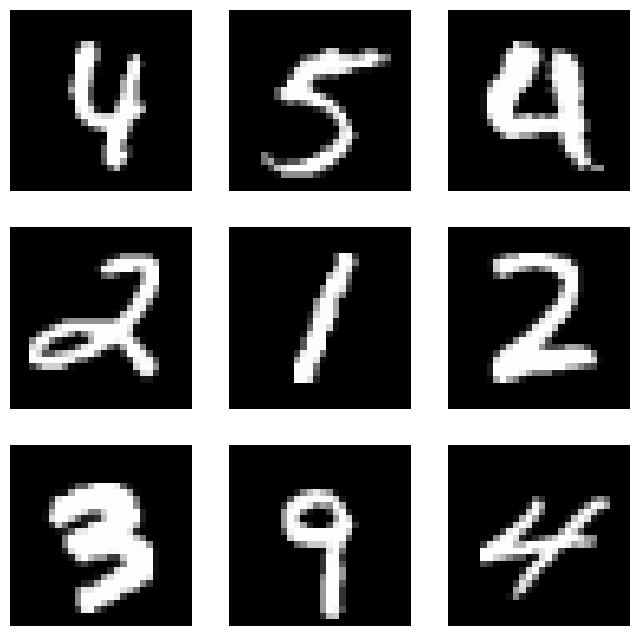

In [26]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [18]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [19]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [21]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [22]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [24]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.179681  [   64/60000]
loss: 2.169288  [ 6464/60000]
loss: 2.190084  [12864/60000]
loss: 2.128356  [19264/60000]
loss: 2.154037  [25664/60000]
loss: 2.154134  [32064/60000]
loss: 2.114656  [38464/60000]
loss: 2.150356  [44864/60000]
loss: 2.092117  [51264/60000]
loss: 2.074233  [57664/60000]
Test Error: 
 Accuracy: 60.3%, Avg loss: 2.076041 

Epoch 2
-------------------------------
loss: 2.065874  [   64/60000]
loss: 2.048410  [ 6464/60000]
loss: 2.084533  [12864/60000]
loss: 1.978164  [19264/60000]
loss: 2.021337  [25664/60000]
loss: 2.017218  [32064/60000]
loss: 1.948067  [38464/60000]
loss: 2.009558  [44864/60000]
loss: 1.917057  [51264/60000]
loss: 1.885498  [57664/60000]
Test Error: 
 Accuracy: 66.8%, Avg loss: 1.886070 

Epoch 3
-------------------------------
loss: 1.877831  [   64/60000]
loss: 1.843502  [ 6464/60000]
loss: 1.899590  [12864/60000]
loss: 1.737817  [19264/60000]
loss: 1.790846  [25664/60000]
loss: 1.779899  [32064/600

In [ ]:
model.eval()
images, labels = next(iter(test_dataloader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    predictions = logits.argmax(dim=1)

figure = plt.figure(figsize=(10, 10))
cols, rows = 3, 3

for i in range(cols * rows):
    ax = figure.add_subplot(rows, cols, i + 1)
    ax.imshow(images[i].cpu().squeeze(), cmap="gray")
    predicted_label = predictions[i].item()
    true_label = labels[i].item()
    ax.set_title(
        f"Pred: {predicted_label} | Real: {true_label}",
        color="green" if predicted_label == true_label else "red",
    )
    ax.axis("off")

plt.tight_layout()
plt.show()